# PK sweep viewer

Interactive exploration of `sim_pk_sweep.h5` (produced by the bottom cell of `simulator_phantom_dce.ipynb`).

Sliders for `ke`, `ve`, `t`; shows the image, k-space (linear or log magnitude), and the tissue concentration curve with the current time marked.

In [16]:
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display

SWEEP_FILE = '/scratch/rnga/vvpshenov/DCE_NIK/sim_pk_sweep.h5'

In [17]:
f = h5py.File(SWEEP_FILE, 'r')
ke_vals = f['/sweep/params/ke'][:]
ve_vals = f['/sweep/params/ve'][:]
times   = f['/sweep/times'][:]
cp_arr  = f['/sweep/pk/cp'][:]
ct_arr  = f['/sweep/pk/ct'][:]              # (n_ke, n_ve, n_t)
roi_idx = int(f['/sweep/pk/roi_idx'][0])
meta    = json.loads(f['/sweep'].attrs['config_json'])

print(f'ke:  {len(ke_vals)} values in [{ke_vals.min():.2f}, {ke_vals.max():.2f}] /min')
print(f've:  {len(ve_vals)} values in [{ve_vals.min():.2f}, {ve_vals.max():.2f}]')
print(f't :  {len(times)} values in [{times.min():.1f}, {times.max():.1f}] s')
print(f'swept ROI: {roi_idx}')
print(f'image  shape: {f["/sweep/image"].shape}')
print(f'kspace shape: {f["/sweep/kspace"].shape}')
print(f'N = {meta["N"]}, oversample = {meta["os_fac"]}x')

ke:  12 values in [0.10, 2.00] /min
ve:  6 values in [0.10, 0.60]
t :  30 values in [0.0, 60.0] s
swept ROI: 2
image  shape: (12, 6, 30, 128, 128)
kspace shape: (12, 6, 30, 128, 128)
N = 128, oversample = 4x


In [18]:
# precompute display limits so colormaps don't jitter when sliding
img_vmax = float(f['/sweep/image'][:].max())
ksp_abs_max_log = float(np.log1p(np.abs(f['/sweep/kspace'][:]).max()))
ksp_abs_max_lin = float(np.abs(f['/sweep/kspace'][:]).max())
ct_max = float(ct_arr.max() * 1.05)
cp_max = float(cp_arr.max() * 1.05)

print(f'img vmax  : {img_vmax:.3f}')
print(f'|k| vmax  : {ksp_abs_max_lin:.3f}   (log1p: {ksp_abs_max_log:.2f})')
print(f'ct vmax   : {ct_max:.3f}')

img vmax  : 0.042
|k| vmax  : 8.130   (log1p: 2.21)
ct vmax   : 0.094


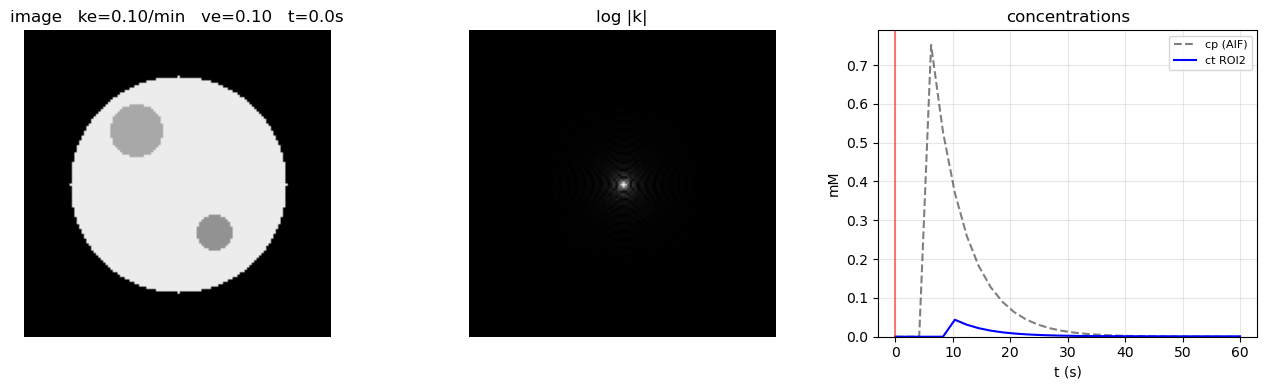

In [19]:
ke_slider = w.IntSlider(0, 0, len(ke_vals)-1, description='ke idx', continuous_update=False)
ve_slider = w.IntSlider(0, 0, len(ve_vals)-1, description='ve idx', continuous_update=False)
t_slider  = w.IntSlider(0, 0, len(times)-1,   description='t idx',  continuous_update=False)
log_k     = w.Checkbox(True, description='log |k|')

out = w.Output()

def _refresh(*_):
    ke_i, ve_i, t_i = ke_slider.value, ve_slider.value, t_slider.value
    img = f['/sweep/image'][ke_i, ve_i, t_i]
    ksp = f['/sweep/kspace'][ke_i, ve_i, t_i]
    ct  = ct_arr[ke_i, ve_i]
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(1, 3, figsize=(13, 4))
        ax[0].imshow(img, cmap='gray', vmin=0, vmax=img_vmax)
        ax[0].set_title(f'image   ke={ke_vals[ke_i]:.2f}/min   ve={ve_vals[ve_i]:.2f}   t={times[t_i]:.1f}s')
        ax[0].axis('off')
        if log_k.value:
            ax[1].imshow(np.log1p(np.abs(ksp)), cmap='gray', vmin=0, vmax=ksp_abs_max_log)
            ax[1].set_title('log |k|')
        else:
            ax[1].imshow(np.abs(ksp), cmap='gray', vmin=0, vmax=ksp_abs_max_lin)
            ax[1].set_title('|k|')
        ax[1].axis('off')
        ax[2].plot(times, cp_arr, 'k--', alpha=0.5, label='cp (AIF)')
        ax[2].plot(times, ct,     'b-',  label=f'ct ROI{roi_idx}')
        ax[2].axvline(times[t_i], color='r', alpha=0.5)
        ax[2].set_xlabel('t (s)'); ax[2].set_ylabel('mM')
        ax[2].set_ylim(0, max(cp_max, ct_max))
        ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3); ax[2].set_title('concentrations')
        plt.tight_layout(); plt.show()

for widget in (ke_slider, ve_slider, t_slider, log_k):
    widget.observe(_refresh, 'value')

display(w.VBox([ke_slider, ve_slider, t_slider, log_k, out]))
_refresh()

## Spoke viewer (1D k-space profile along a radial line)

Pick a spoke angle. Extract k-space values along that line through the origin via bilinear interpolation of the stored 2D k-grid. Plot Re, Im, and log(1+|k|) along the readout index (DC at the centre). Four sliders: `ke`, `ve`, `t`, `angle`.

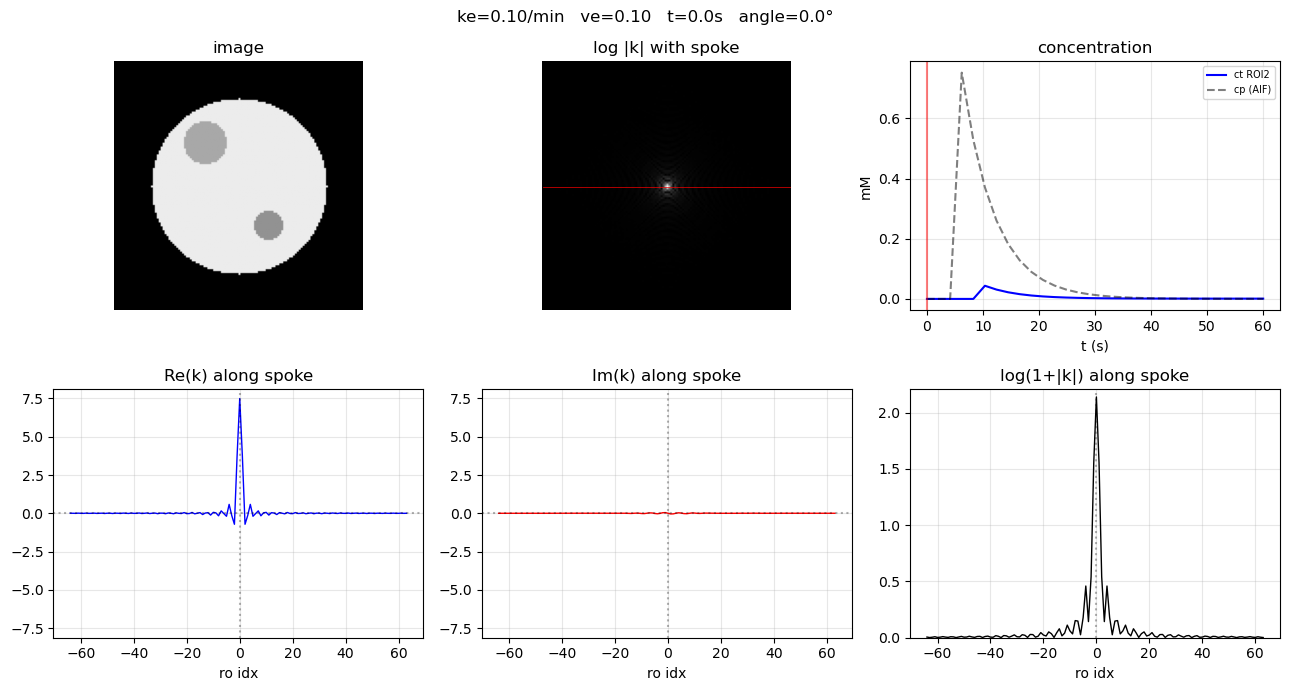

In [20]:
from scipy.ndimage import map_coordinates

def extract_spoke(k_2d, angle_rad, RO):
    # k_2d: (N, N) complex, centered (DC at N//2)
    # angle_rad: spoke direction
    # returns (RO,) complex along the full line through origin
    N = k_2d.shape[0]
    kr = np.linspace(-0.5, 0.5 - 1.0/RO, RO)
    kx = kr * np.cos(angle_rad)
    ky = kr * np.sin(angle_rad)
    px = kx * N + N / 2.0
    py = ky * N + N / 2.0
    coords = np.stack([py, px], axis=0)
    re = map_coordinates(k_2d.real, coords, order=1, mode='constant', cval=0.0)
    im = map_coordinates(k_2d.imag, coords, order=1, mode='constant', cval=0.0)
    return re + 1j * im

RO_spoke     = 128
n_angles     = 72                                            # 0..180 deg in 2.5 deg steps
angle_grid   = np.linspace(0.0, np.pi, n_angles, endpoint=False)
ro_axis      = np.arange(RO_spoke) - RO_spoke // 2          # centered, DC at 0

re_max = ksp_abs_max_lin
im_max = ksp_abs_max_lin
log_max = ksp_abs_max_log

ke_s2 = w.IntSlider(0, 0, len(ke_vals)-1, description='ke idx', continuous_update=False)
ve_s2 = w.IntSlider(0, 0, len(ve_vals)-1, description='ve idx', continuous_update=False)
t_s2  = w.IntSlider(0, 0, len(times)-1,   description='t idx',  continuous_update=False)
a_s2  = w.IntSlider(0, 0, n_angles-1,     description='angle',  continuous_update=False)

out_spoke = w.Output()

def _refresh_spoke(*_):
    ke_i, ve_i, t_i, a_i = ke_s2.value, ve_s2.value, t_s2.value, a_s2.value
    k_2d  = f['/sweep/kspace'][ke_i, ve_i, t_i]
    img   = f['/sweep/image'][ke_i, ve_i, t_i]
    angle = angle_grid[a_i]
    spoke = extract_spoke(k_2d, angle, RO_spoke)
    # where the spoke is in the 2D grid (for overlay)
    N = k_2d.shape[0]
    px = (np.linspace(-0.5, 0.5 - 1.0/RO_spoke, RO_spoke) * N * np.cos(angle)) + N/2
    py = (np.linspace(-0.5, 0.5 - 1.0/RO_spoke, RO_spoke) * N * np.sin(angle)) + N/2
    with out_spoke:
        out_spoke.clear_output(wait=True)
        fig, ax = plt.subplots(2, 3, figsize=(13, 7))
        # top row: 2D context (image, |k| with spoke overlay, spoke location diagram)
        ax[0, 0].imshow(img, cmap='gray', vmin=0, vmax=img_vmax); ax[0, 0].set_title('image'); ax[0, 0].axis('off')
        ax[0, 1].imshow(np.log1p(np.abs(k_2d)), cmap='gray', vmin=0, vmax=log_max); ax[0, 1].set_title('log |k| with spoke'); ax[0, 1].axis('off')
        ax[0, 1].plot(px, py, 'r-', lw=0.6, alpha=0.8)
        ax[0, 2].plot(times, ct_arr[ke_i, ve_i], 'b-', label=f'ct ROI{roi_idx}')
        ax[0, 2].plot(times, cp_arr, 'k--', alpha=0.5, label='cp (AIF)')
        ax[0, 2].axvline(times[t_i], color='r', alpha=0.5)
        ax[0, 2].set_xlabel('t (s)'); ax[0, 2].set_ylabel('mM'); ax[0, 2].legend(fontsize=7); ax[0, 2].grid(alpha=0.3); ax[0, 2].set_title('concentration')
        # bottom row: 1D spoke profiles
        ax[1, 0].plot(ro_axis, spoke.real, 'b-', lw=1)
        ax[1, 0].axvline(0, color='k', ls=':', alpha=0.3); ax[1, 0].axhline(0, color='k', ls=':', alpha=0.3)
        ax[1, 0].set_ylim(-re_max, re_max); ax[1, 0].set_title('Re(k) along spoke'); ax[1, 0].set_xlabel('ro idx'); ax[1, 0].grid(alpha=0.3)
        ax[1, 1].plot(ro_axis, spoke.imag, 'r-', lw=1)
        ax[1, 1].axvline(0, color='k', ls=':', alpha=0.3); ax[1, 1].axhline(0, color='k', ls=':', alpha=0.3)
        ax[1, 1].set_ylim(-im_max, im_max); ax[1, 1].set_title('Im(k) along spoke'); ax[1, 1].set_xlabel('ro idx'); ax[1, 1].grid(alpha=0.3)
        ax[1, 2].plot(ro_axis, np.log1p(np.abs(spoke)), 'k-', lw=1)
        ax[1, 2].axvline(0, color='k', ls=':', alpha=0.3)
        ax[1, 2].set_ylim(0, log_max); ax[1, 2].set_title('log(1+|k|) along spoke'); ax[1, 2].set_xlabel('ro idx'); ax[1, 2].grid(alpha=0.3)
        fig.suptitle(f'ke={ke_vals[ke_i]:.2f}/min   ve={ve_vals[ve_i]:.2f}   t={times[t_i]:.1f}s   angle={np.degrees(angle):.1f}°')
        plt.tight_layout(); plt.show()

for widget in (ke_s2, ve_s2, t_s2, a_s2):
    widget.observe(_refresh_spoke, 'value')

display(w.VBox([ke_s2, ve_s2, t_s2, a_s2, out_spoke]))
_refresh_spoke()

## Time evolution of one spoke (all times overlaid)

Fixed `ke`, `ve`, `angle`. Overlays all 30 time points colored by time. Shows whether the spoke shape **deforms smoothly** over time (continuous function NIK can fit easily) or jumps / flips sign (harder to interpolate).

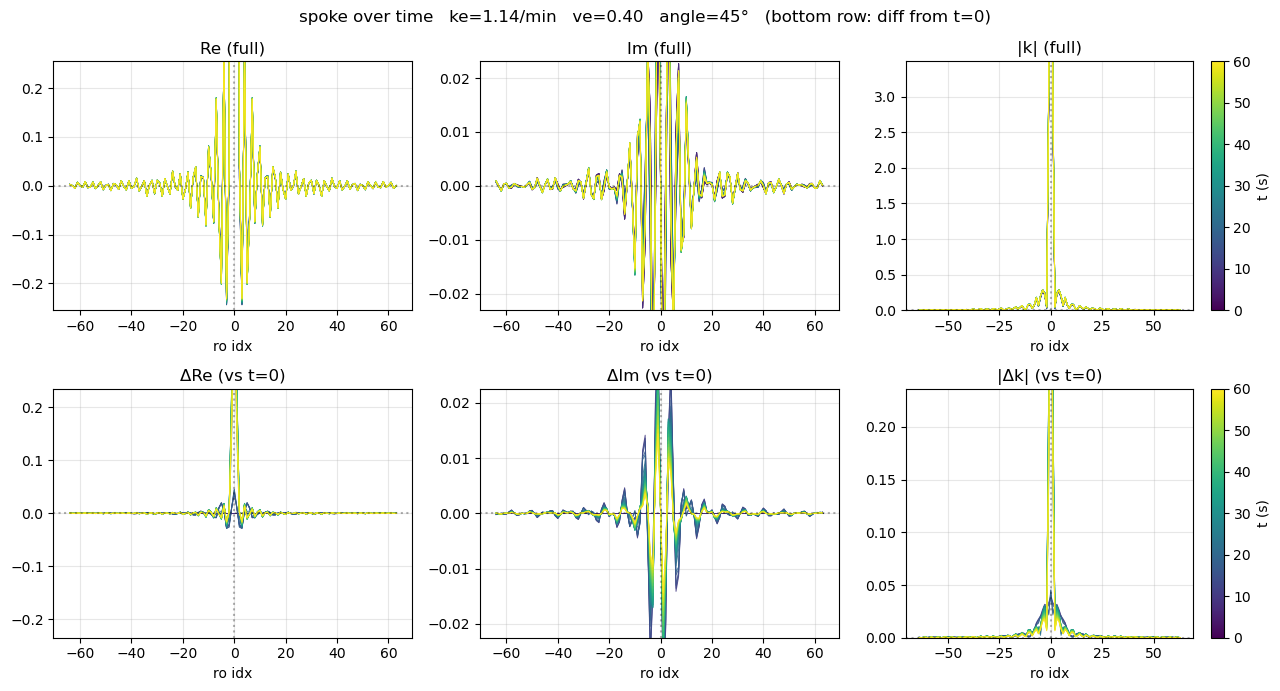

In [21]:
ke_i_fix    = len(ke_vals) // 2
ve_i_fix    = len(ve_vals) // 2
angle_fix   = np.pi / 4

# collect all spokes for this slice
spokes = np.stack([extract_spoke(f['/sweep/kspace'][ke_i_fix, ve_i_fix, t_i], angle_fix, RO_spoke)
                   for t_i in range(len(times))], axis=0)  # (n_t, RO)
spokes_diff = spokes - spokes[0:1]                         # difference from t=0 baseline

# percentile-based y limits (robust to DC spike)
re_lim      = np.percentile(np.abs(spokes.real),      95) * 1.1
im_lim      = np.percentile(np.abs(spokes.imag),      95) * 1.1
re_diff_lim = np.percentile(np.abs(spokes_diff.real), 99) * 1.1 + 1e-12
im_diff_lim = np.percentile(np.abs(spokes_diff.imag), 99) * 1.1 + 1e-12
mag_lim     = np.percentile(np.abs(spokes),           99) * 1.1
mag_diff_lim = np.percentile(np.abs(spokes_diff),     99) * 1.1 + 1e-12

fig, ax = plt.subplots(2, 3, figsize=(13, 7))
for t_i in range(len(times)):
    color = plt.cm.viridis(t_i / max(len(times)-1, 1))
    ax[0, 0].plot(ro_axis, spokes[t_i].real,           color=color, lw=0.7, alpha=0.85)
    ax[0, 1].plot(ro_axis, spokes[t_i].imag,           color=color, lw=0.7, alpha=0.85)
    ax[0, 2].plot(ro_axis, np.abs(spokes[t_i]),         color=color, lw=0.7, alpha=0.85)
    ax[1, 0].plot(ro_axis, spokes_diff[t_i].real,      color=color, lw=0.7, alpha=0.85)
    ax[1, 1].plot(ro_axis, spokes_diff[t_i].imag,      color=color, lw=0.7, alpha=0.85)
    ax[1, 2].plot(ro_axis, np.abs(spokes_diff[t_i]),   color=color, lw=0.7, alpha=0.85)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(times.min(), times.max()))
plt.colorbar(sm, ax=ax[0, 2], label='t (s)')
plt.colorbar(sm, ax=ax[1, 2], label='t (s)')

ax[0, 0].set_ylim(-re_lim, re_lim);   ax[0, 0].set_title('Re (full)')
ax[0, 1].set_ylim(-im_lim, im_lim);   ax[0, 1].set_title('Im (full)')
ax[0, 2].set_ylim(0,        mag_lim); ax[0, 2].set_title('|k| (full)')
ax[1, 0].set_ylim(-re_diff_lim,  re_diff_lim);  ax[1, 0].set_title('ΔRe (vs t=0)')
ax[1, 1].set_ylim(-im_diff_lim,  im_diff_lim);  ax[1, 1].set_title('ΔIm (vs t=0)')
ax[1, 2].set_ylim(0,              mag_diff_lim); ax[1, 2].set_title('|Δk| (vs t=0)')
for a in ax.flat:
    a.axvline(0, color='k', ls=':', alpha=0.3); a.axhline(0, color='k', ls=':', alpha=0.3)
    a.set_xlabel('ro idx'); a.grid(alpha=0.3)
fig.suptitle(f'spoke over time   ke={ke_vals[ke_i_fix]:.2f}/min   ve={ve_vals[ve_i_fix]:.2f}   angle={np.degrees(angle_fix):.0f}°   (bottom row: diff from t=0)')
plt.tight_layout(); plt.show()

## PK effect on one spoke at a fixed time (all `ke` overlaid)

Fixed `t`, `ve`, `angle`. Overlays all 12 `ke` values colored by ke. If the spoke shape maps continuously to ke, PK parameters are (in principle) recoverable from the spoke pattern. If all curves overlap, ke is invisible to this spoke at this time.

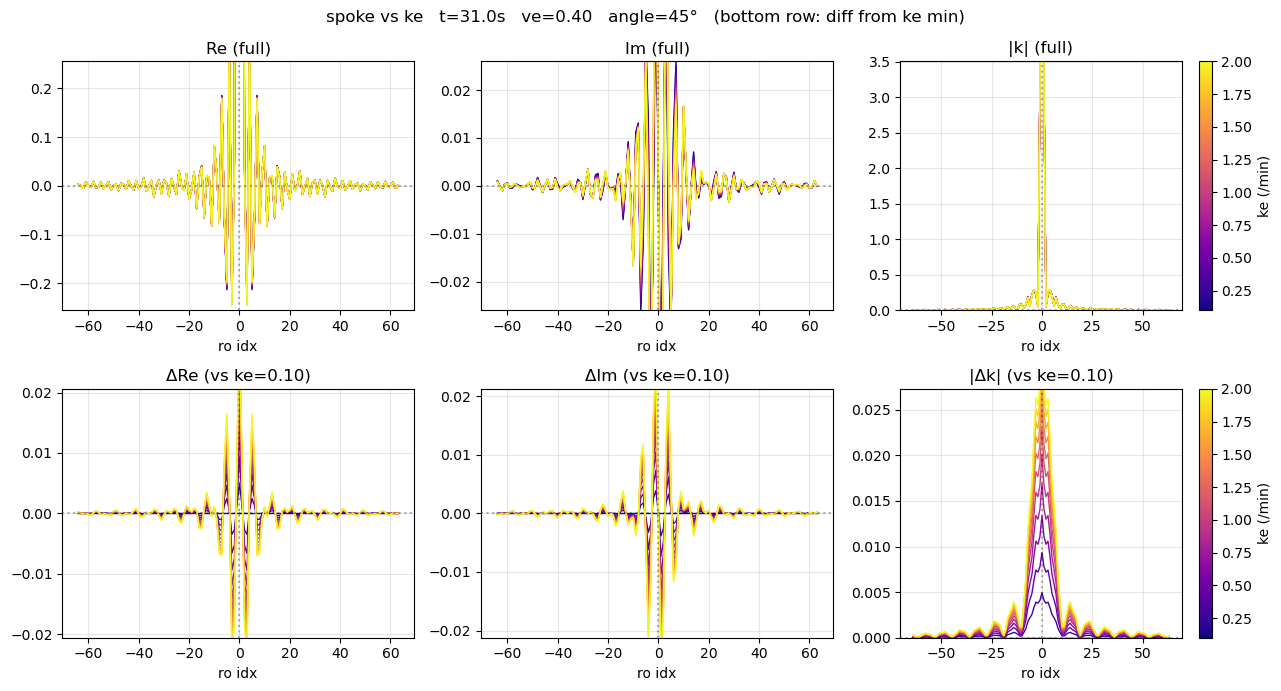

In [22]:
t_i_fix   = 15
ve_i_fix  = len(ve_vals) // 2
angle_fix = np.pi / 4

# reference = lowest ke at same (ve, t)
spokes_ke = np.stack([extract_spoke(f['/sweep/kspace'][ke_i, ve_i_fix, t_i_fix], angle_fix, RO_spoke)
                      for ke_i in range(len(ke_vals))], axis=0)   # (n_ke, RO)
spokes_ke_diff = spokes_ke - spokes_ke[0:1]

re_lim      = np.percentile(np.abs(spokes_ke.real),       95) * 1.1
im_lim      = np.percentile(np.abs(spokes_ke.imag),       95) * 1.1
re_diff_lim = np.percentile(np.abs(spokes_ke_diff.real),  99) * 1.1 + 1e-12
im_diff_lim = np.percentile(np.abs(spokes_ke_diff.imag),  99) * 1.1 + 1e-12
mag_lim      = np.percentile(np.abs(spokes_ke),           99) * 1.1
mag_diff_lim = np.percentile(np.abs(spokes_ke_diff),      99) * 1.1 + 1e-12

fig, ax = plt.subplots(2, 3, figsize=(13, 7))
for ke_i in range(len(ke_vals)):
    color = plt.cm.plasma(ke_i / max(len(ke_vals)-1, 1))
    ax[0, 0].plot(ro_axis, spokes_ke[ke_i].real,      color=color, lw=1)
    ax[0, 1].plot(ro_axis, spokes_ke[ke_i].imag,      color=color, lw=1)
    ax[0, 2].plot(ro_axis, np.abs(spokes_ke[ke_i]),    color=color, lw=1)
    ax[1, 0].plot(ro_axis, spokes_ke_diff[ke_i].real, color=color, lw=1)
    ax[1, 1].plot(ro_axis, spokes_ke_diff[ke_i].imag, color=color, lw=1)
    ax[1, 2].plot(ro_axis, np.abs(spokes_ke_diff[ke_i]), color=color, lw=1)

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(ke_vals.min(), ke_vals.max()))
plt.colorbar(sm, ax=ax[0, 2], label='ke (/min)')
plt.colorbar(sm, ax=ax[1, 2], label='ke (/min)')

ax[0, 0].set_ylim(-re_lim, re_lim);    ax[0, 0].set_title('Re (full)')
ax[0, 1].set_ylim(-im_lim, im_lim);    ax[0, 1].set_title('Im (full)')
ax[0, 2].set_ylim(0,        mag_lim);  ax[0, 2].set_title('|k| (full)')
ax[1, 0].set_ylim(-re_diff_lim,  re_diff_lim);  ax[1, 0].set_title(f'ΔRe (vs ke={ke_vals[0]:.2f})')
ax[1, 1].set_ylim(-im_diff_lim,  im_diff_lim);  ax[1, 1].set_title(f'ΔIm (vs ke={ke_vals[0]:.2f})')
ax[1, 2].set_ylim(0,              mag_diff_lim); ax[1, 2].set_title(f'|Δk| (vs ke={ke_vals[0]:.2f})')
for a in ax.flat:
    a.axvline(0, color='k', ls=':', alpha=0.3); a.axhline(0, color='k', ls=':', alpha=0.3)
    a.set_xlabel('ro idx'); a.grid(alpha=0.3)
fig.suptitle(f'spoke vs ke   t={times[t_i_fix]:.1f}s   ve={ve_vals[ve_i_fix]:.2f}   angle={np.degrees(angle_fix):.0f}°   (bottom row: diff from ke min)')
plt.tight_layout(); plt.show()

## Grid view: fixed `ve`, scan `ke` across a row of k-space snapshots at a chosen time

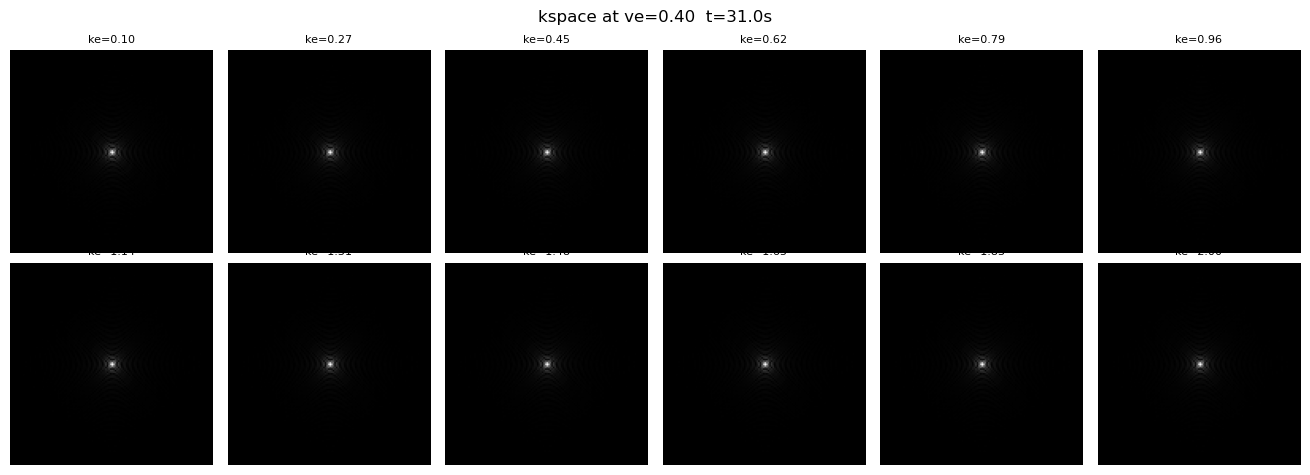

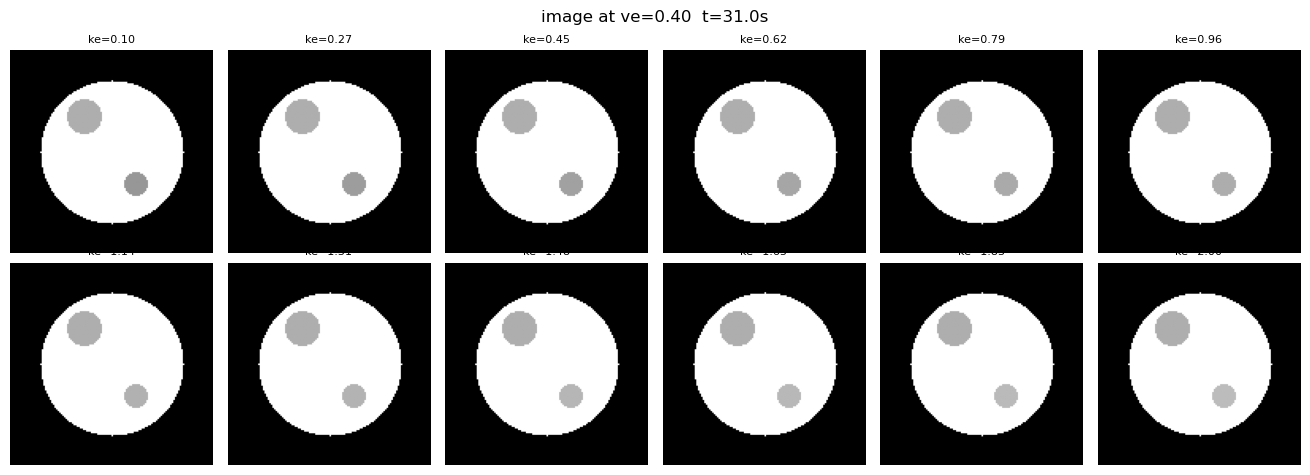

In [23]:
def grid_snapshot(t_i, ve_i, log_scale=True, what='kspace'):
    # show all ke values at fixed ve, one time point
    cols = min(len(ke_vals), 6)
    rows = (len(ke_vals) + cols - 1) // cols
    fig, ax = plt.subplots(rows, cols, figsize=(2.2*cols, 2.4*rows))
    ax = np.atleast_2d(ax)
    for i, ke in enumerate(ke_vals):
        r, cc = divmod(i, cols)
        if what == 'kspace':
            im = f['/sweep/kspace'][i, ve_i, t_i]
            disp = np.log1p(np.abs(im)) if log_scale else np.abs(im)
            vmax = ksp_abs_max_log if log_scale else ksp_abs_max_lin
            ax[r, cc].imshow(disp, cmap='gray', vmin=0, vmax=vmax)
        else:
            im = f['/sweep/image'][i, ve_i, t_i]
            ax[r, cc].imshow(im, cmap='gray', vmin=0, vmax=img_vmax)
        ax[r, cc].set_title(f'ke={ke:.2f}', fontsize=8); ax[r, cc].axis('off')
    for j in range(len(ke_vals), rows*cols):
        r, cc = divmod(j, cols); ax[r, cc].axis('off')
    fig.suptitle(f'{what} at ve={ve_vals[ve_i]:.2f}  t={times[t_i]:.1f}s')
    plt.tight_layout(); plt.show()

# example: fixed ve = middle, time = middle
grid_snapshot(t_i=len(times)//2, ve_i=len(ve_vals)//2, log_scale=True, what='kspace')
grid_snapshot(t_i=len(times)//2, ve_i=len(ve_vals)//2, log_scale=False, what='image')

## ct(t) fan: concentration curves for all (ke, ve) pairs

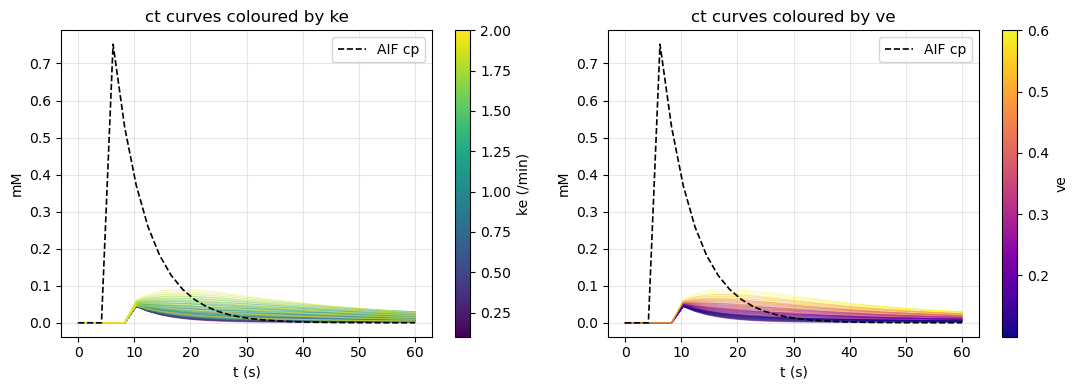

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for ke_i, ke in enumerate(ke_vals):
    for ve_i, ve in enumerate(ve_vals):
        ax[0].plot(times, ct_arr[ke_i, ve_i], color=plt.cm.viridis(ke_i/max(len(ke_vals)-1, 1)), alpha=0.35, lw=0.8)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(ke_vals.min(), ke_vals.max()))
plt.colorbar(sm, ax=ax[0], label='ke (/min)')
ax[0].plot(times, cp_arr, 'k--', lw=1.2, label='AIF cp')
ax[0].set_xlabel('t (s)'); ax[0].set_ylabel('mM'); ax[0].set_title('ct curves coloured by ke'); ax[0].legend(); ax[0].grid(alpha=0.3)

for ke_i, ke in enumerate(ke_vals):
    for ve_i, ve in enumerate(ve_vals):
        ax[1].plot(times, ct_arr[ke_i, ve_i], color=plt.cm.plasma(ve_i/max(len(ve_vals)-1, 1)), alpha=0.35, lw=0.8)
sm2 = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(ve_vals.min(), ve_vals.max()))
plt.colorbar(sm2, ax=ax[1], label='ve')
ax[1].plot(times, cp_arr, 'k--', lw=1.2, label='AIF cp')
ax[1].set_xlabel('t (s)'); ax[1].set_ylabel('mM'); ax[1].set_title('ct curves coloured by ve'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()